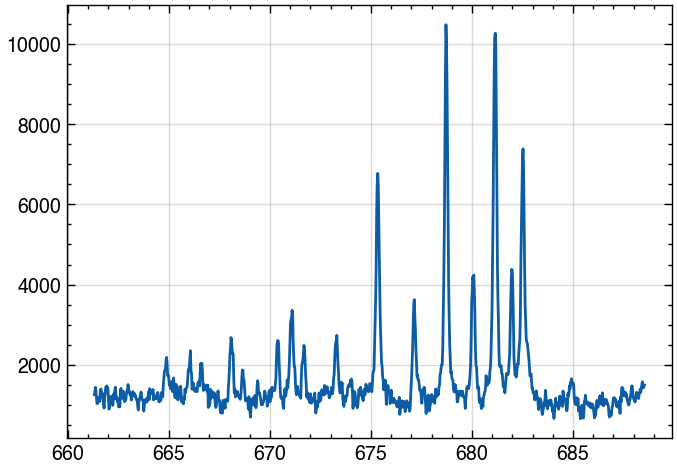

In [2]:
from ramlab.calculate_molecules.H2 import H2
import matplotlib.pyplot as plt
import wedme.apply.dev
import numpy as np
from ramlab.calculate_molecules.calculated_linelist_molecule import CalculatedLinelistMolecule
from ramlab.simulate_spectrum import simulate, simulate_raw
from toddler.data.spectrum import Spectrum
import pickle
from pathlib import Path

def get_data(data, info, config):
    # Get the keys for the signal and background indices
    sig_key = f"{config}_sig"
    bg_key = f"{config}_bg"

    if not sig_key in info:
        return None, None

    # Get the indices for the signal and background
    sig_ind = info[sig_key]
    bg_ind = info[bg_key]

    # Get the data for the signal and background
    sig_data = data[:, :, sig_ind[0]]
    bg_data = data[:, :, bg_ind[0]]

    sig_data_avg = sig_data.c.median(axis=2)
    bg_data_avg = bg_data.c.median(axis=2)

    return sig_data_avg, bg_data_avg, sig_data_avg - bg_data_avg


def get_polarised_signals(f_data, f_pickle=None):
    if f_pickle is None:
        f_pickle = f_data.with_stem(f_data.stem + "_idx").with_suffix(".pkl")

    # Load pickle file
    info = pickle.load(open(f_pickle, "rb"))

    # Load sif file
    data = Spectrum.from_file(f_data, new_axes=True)
    data._axis_lambda = 0

    # Load the data of all config
    # (sig, bg, sig-bg)
    sig_ver, bg_ver, sig_ver_corr = get_data(data, info, 0)
    sig_hor, bg_hor, sig_hor_corr = get_data(data, info, 1)

    return sig_ver_corr, sig_hor_corr



dir_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250107")
# f_pickle = dir_data / "05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp_idx.pkl"
# f_data = dir_data / "05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp.sif"
f_pickle = dir_data / "02_06slmH2_04slmCH4_01slmAr_075mbar_0700W_idx.pkl"
f_data = dir_data / "02_06slmH2_04slmCH4_01slmAr_075mbar_0700W_g3c675.sif"


ver, hor = get_polarised_signals(f_data, f_pickle)
ver_roomtemp, hor_roomtemp = get_polarised_signals(dir_data / "05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp.sif")

plt.plot(ver.lambdanm, ver.sdata)

Generating linelist file...
Calculating cross-section
Calculating cross-section


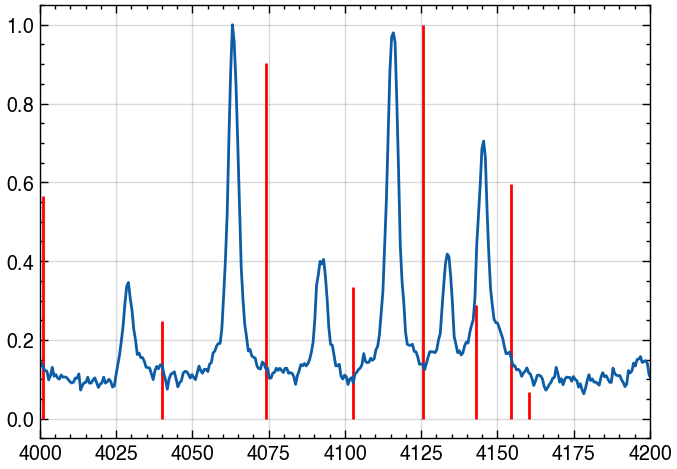

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 81
    # data points      = 1024
    # variables        = 5
    chi-square         = 2.1981e-06
    reduced chi-square = 2.1571e-09
    Akaike info crit   = -20428.4262
    Bayesian info crit = -20403.7688
[[Variables]]
    A:                    1 (fixed)
    T:                    313.018408 +/- 0.76779730 (0.25%) (init = 300)
    w_g:                  1.03980383 +/- 0.00832873 (0.80%) (init = 1.031179)
    w_l:                  1.16858732 +/- 0.00980970 (0.84%) (init = 1.178945)
    lambda_correction_0:  0.38168140 +/- 0.00613686 (1.61%) (init = 0.3828132)
    lambda_correction_1: -0.16624666 +/- 0.01090398 (6.56%) (init = -0.1681828)
[[Correlations]] (unreported correlations are < 0.100)
    C(lambda_correction_0, lambda_correction_1) = -0.9999
    C(w_g, w_l)                               = -0.9637
    C(T, lambda_correction_0)                   = +0.2670
    C(T, lambda_correction_1)                   = -0

In [28]:
from lmfit import minimize, Parameters, fit_report
from ramlab.simulate_spectrum.linespreadfunction.functions import gaussian, voigt, lorentzian, rect, martijnian

from ttictoc import tic,toc


from ramlab.fit.modifiers import *
from ramlab.state.polarisation import Polarisation


M = CalculatedLinelistMolecule(H2)
transitions = M.all_transitions(laser_wavelength=532e-9, force_recalculate=True)
transitions = transitions[transitions.dv == 1]
transitions = transitions[transitions.dJ == 0]
transitions = transitions[transitions.initial_J < 12]
transitions = transitions[transitions.crosssection != np.nan]

I_const_par = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PARALLEL)
I_const_per = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PERPENDICULAR)
I_var = M.get_intensity_variable(transitions, T=2500)

I = (I_const_par + I_const_per) * I_var
I /= np.nanmax(I)
dnu = M.dE(transitions)

plt.vlines(dnu, 0, I, 'r')
plt.plot(ver.dnu()/1e2, ver.c.normalize(axis=0).sdata)
plt.xlim(4000, 4200)
plt.show()


fitParameters = Parameters()
fitParameters.add("A", value=1, vary=False)
fitParameters.add("T", value=300, vary=True)
fitParameters.add("w_g", value=1.03117895, min=0, vary=False)
fitParameters.add("w_l", value=1.17894516, min=0, vary=False)
fitParameters.add("beun", value=1, min=0, vary=True)

wavelengthCorrection = WavelengthAxisCorrection(1)
wavelengthCorrection.add_parameters(fitParameters, initial_values=[0.38281319, -0.16818279], vary=False)

def spectral_fit_residuals(pars: Parameters, meas_ver, meas_hor, I_const_per, I_const_par, test=False):
    tic()
    A = pars['A']
    T = pars['T']
    w_g = pars['w_g']
    w_l = pars['w_l']

    meas_ver = MeasurementSpectrum(meas_ver)
    meas_ver = wavelengthCorrection.modify(meas_ver, pars)
    meas_ver = meas_ver.data

    meas_hor = MeasurementSpectrum(meas_hor)
    meas_hor = wavelengthCorrection.modify(meas_hor, pars)
    meas_hor = meas_hor.data

    meas = meas.data
    dnu_meas = meas.dnu()/1e2, 
    I_meas = meas.c.normalize(axis=0).sdata


    I_var = M.get_intensity_variable(transitions, T=T)
    I_stick_sim = (I_const_per) * I_var
    # I_stick_sim = (I_const_per + I_const_par) * I_var
    I_stick_sim /= np.nanmax(I_stick_sim)

    dnu_stick = transitions.vacuum_wavenumber

    I_sim_broad = simulate_raw(dnu_meas, dnu_stick, I_stick_sim, w_g, w_l)
    I_sim_broad *= A / np.nanmax(I_sim_broad)

    # print(f"Execution time: {toc()*1e3:.0f}ms")

    if test is True:
        return I_sim_broad

    return (I_sim_broad - I_meas)**2

s = ver_roomtemp
# s = s

out = minimize(spectral_fit_residuals, fitParameters, args=(ver.c, hor.c, I_const_per, I_const_par))
spectral_fit_residuals(fitParameters, ver.c, hor.c, I_const_per, I_const_par, test=True)

print(fit_report(out))

(4000.0, 4200.0)

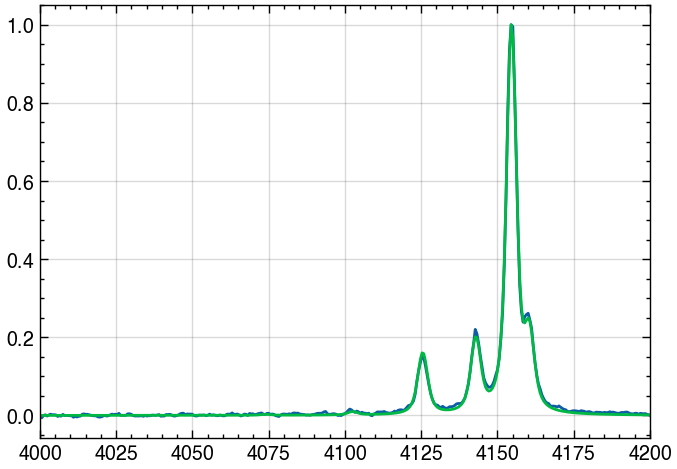

In [29]:
s2 = wavelengthCorrection.modify(MeasurementSpectrum(s.c), out.params).data

plt.figure()
plt.plot(s2.dnu()/1e2, s2.c.normalize(axis=0).sdata)
plt.plot(s2.dnu()/1e2, spectral_fit_residuals(out.params, s.c.normalize(axis=0), I_const_per, I_const_par, test=True))
plt.xlim(4000, 4200)